In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

mpl.rcParams['image.cmap'] = 'bwr'

from src import *

# Experiment 1

Hypothesis:

- Uniform $\mathcal{X}$ distribution (shouldn't impact the results)
- Each pixel $y_i$ from the ground-truth is drawn from a beta distribution with $a=b=0.5$. This renders the output probability separable, i.e., $$P(Y=y|X=x) = \prod_{i=1}^{n} P(Y_i=y_i|X=x)$$
- Output probability distribution is known, i.e., $\forall i$, we can compute $P(Y_i=y_i|X=x)$

In [3]:
# random pixel-level output probability
Pyi = np.array([np.random.RandomState(x).beta(a=0.5, b=0.5, size=(3,3)) for x in range(2**9)])

# image-level output probability derived from pixel-level probabilities
Py = [np.array([np.where(int2img(y), Pyi[x], 1 - Pyi[x]).prod() for y in range(2**9)]) for x in range(2**9)]

## Example

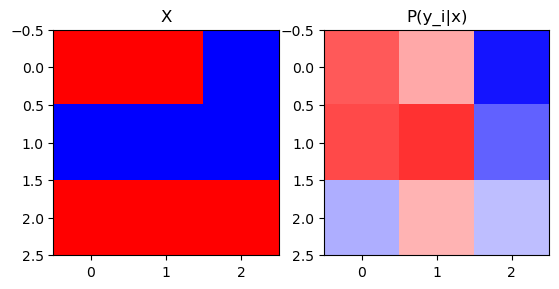

In [4]:
x = np.random.choice(2**9)

fig, axs = plt.subplots(1, 2)

axs[0].imshow(int2img(x))
axs[0].set_title('X')

axs[1].imshow(Pyi[x], vmin=0, vmax=1)
axs[1].set_title('P(y_i|x)')

plt.show()

## 0-1 & accuracy ideal model

The ideal model for the 0-1 loss is $$ h(x) = \arg\max_{\hat{y}} \, P(Y=\hat{y}|X=x). $$
Because the probability is separable, it is easy to see that this model is also the ideal model for the accuracy loss.

In [5]:
# most probable output
h = lambda x: np.argmax(Py[x])

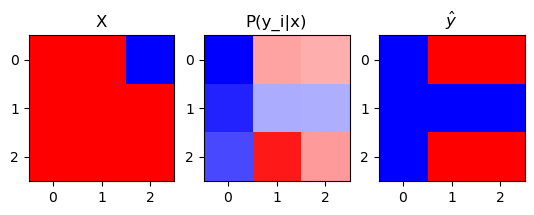

In [6]:
## EXAMPLE
x = np.random.choice(2**9)
y_hat = h(x)

fig, axs = plt.subplots(1, 3)

axs[0].imshow(int2img(x))
axs[0].set_title('X')

axs[1].imshow(Pyi[x], vmin=0, vmax=1)
axs[1].set_title('P(y_i|x)')

axs[2].imshow(int2img(y_hat))
axs[2].set_title(r'$\hat{y}$')

plt.show()

### Losses

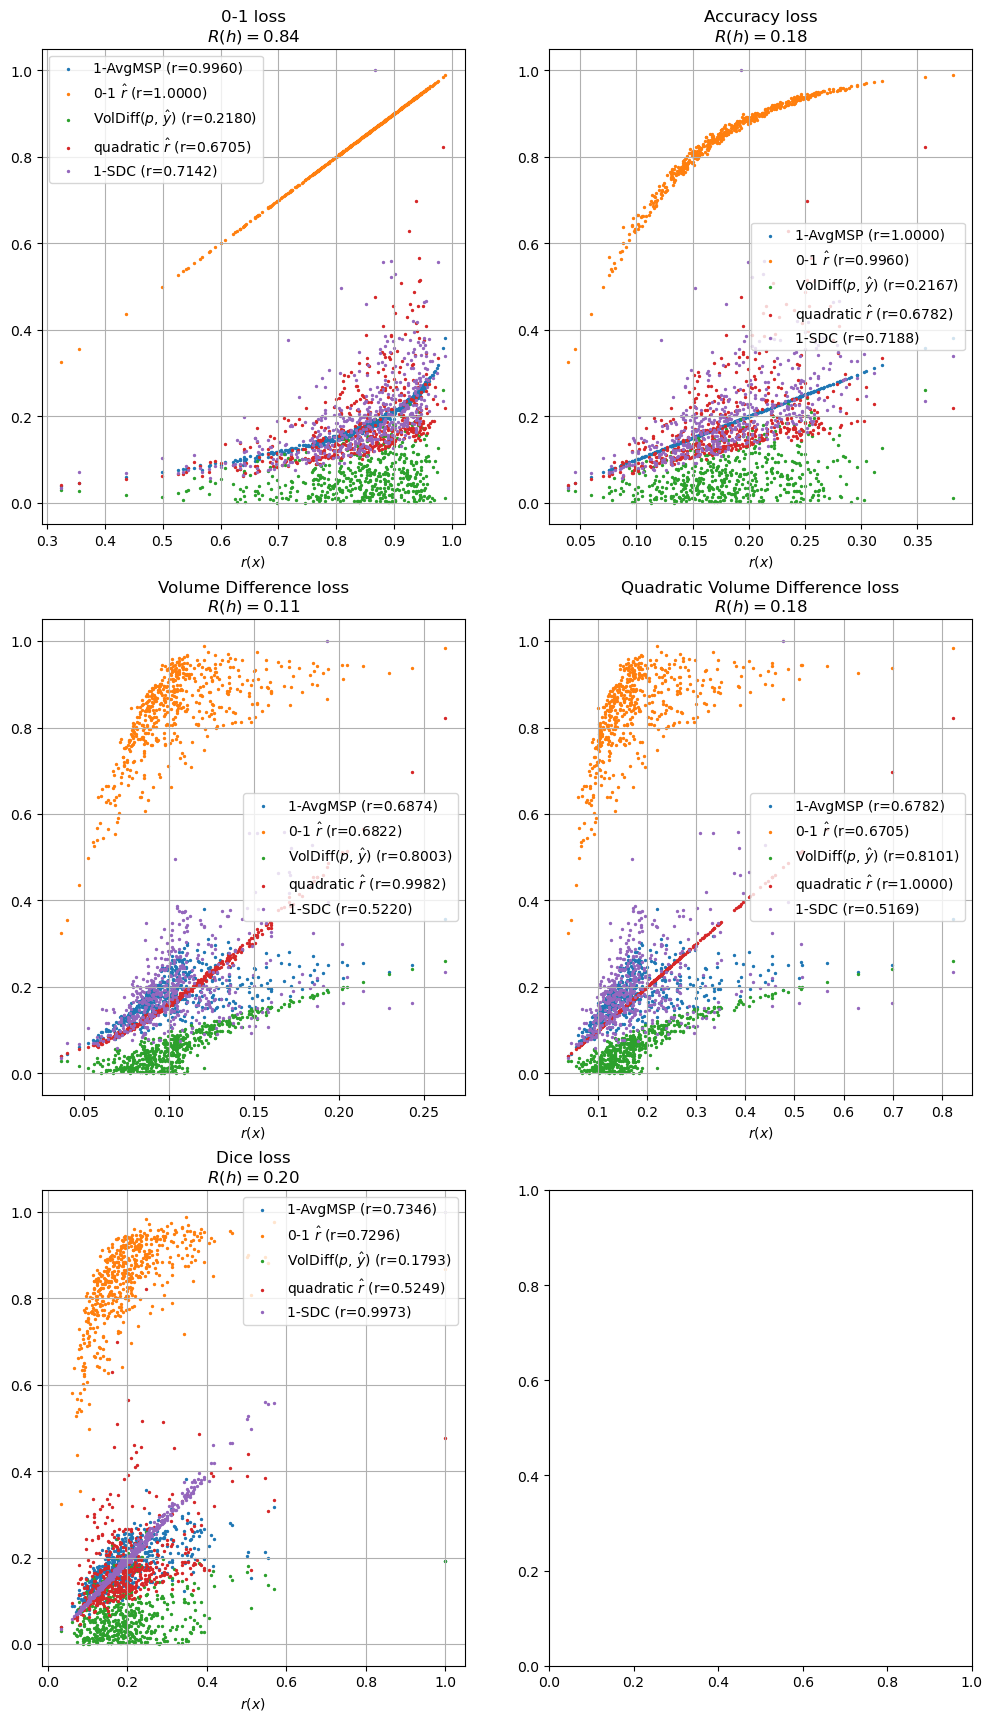

In [7]:
all_plots = [plot_01_loss, plot_accuracy_loss, plot_voldiff_loss, plot_quadvoldiff_loss, plot_dice_loss]
# fig, axs = plt.subplots(len(all_plots), 1, squeeze=True)
fig, axs = plt.subplots(int(len(all_plots)/2 + 0.5), 2, squeeze=True)
fig.set_size_inches(2*6, 7*int(len(all_plots)/2 + 0.5))

for plot_loss, ax in zip(all_plots, axs.flatten()):
    plot_loss(h, Py, Pyi, ax=ax)
plt.show()

### RC Curves

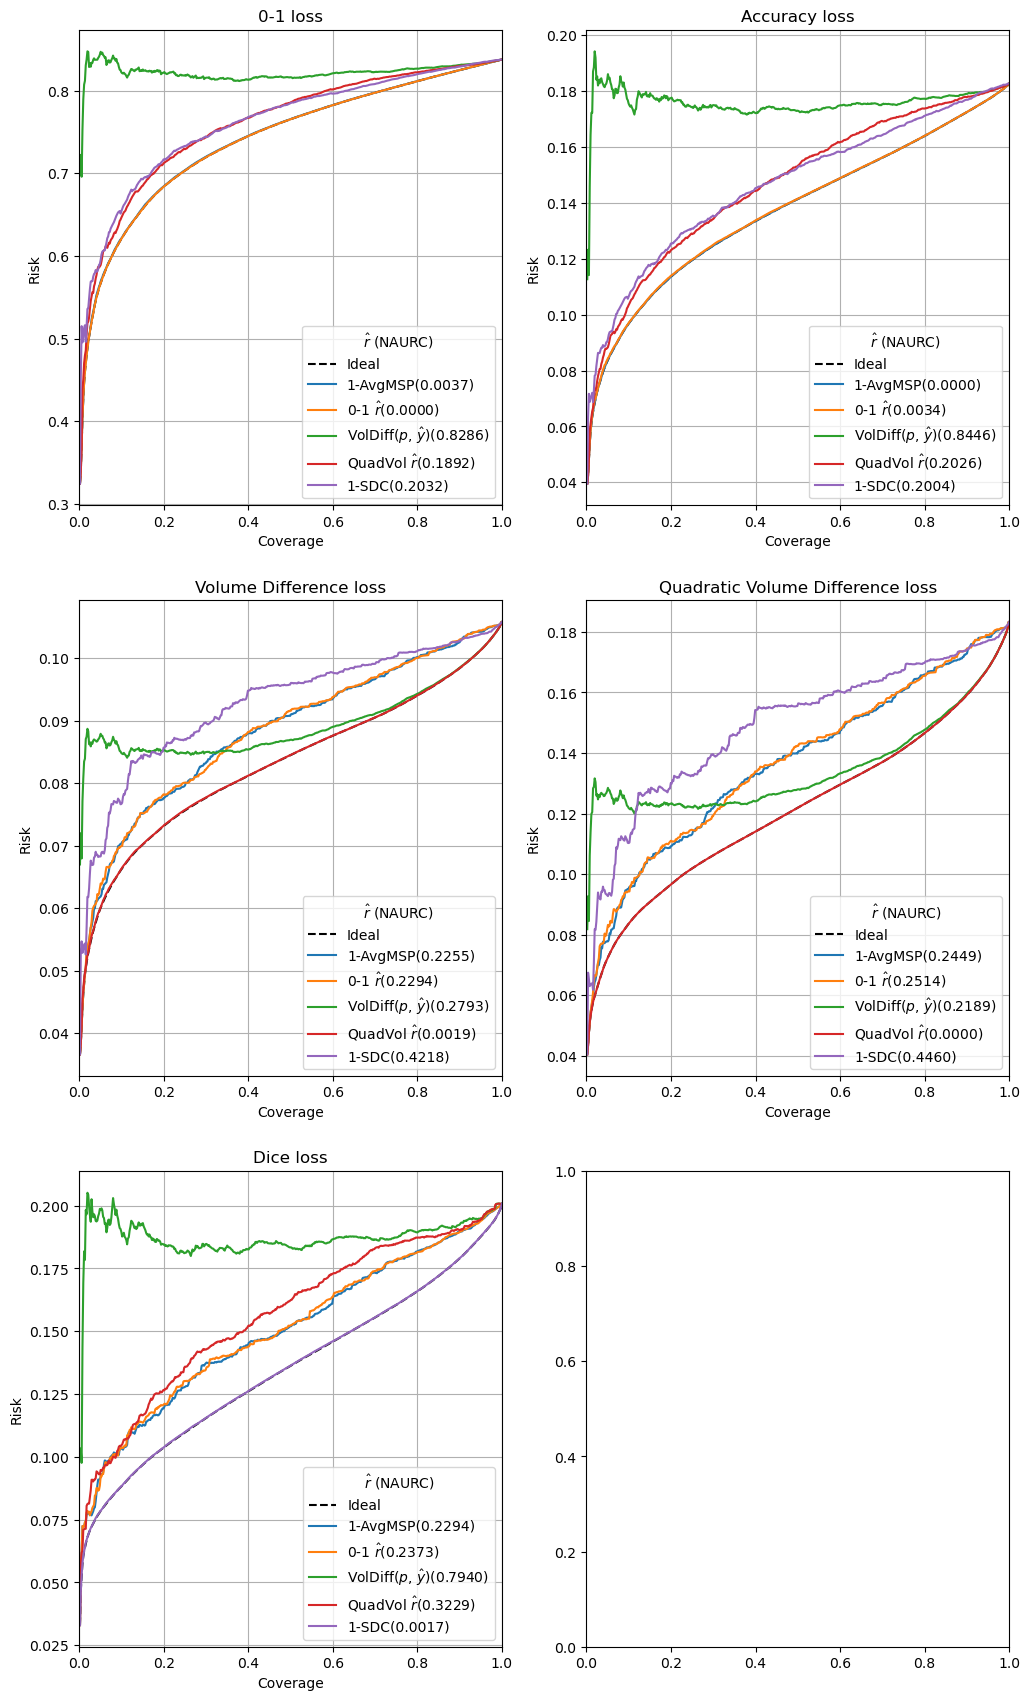

In [8]:
all_plots = [plot_01_rc, plot_accuracy_rc, plot_voldiff_rc, plot_quadvoldiff_rc, plot_dice_rc]
# fig, axs = plt.subplots(len(all_plots), 1, squeeze=True)
fig, axs = plt.subplots(int(len(all_plots)/2 + 0.5), 2, squeeze=True)
fig.set_size_inches(2*6, 7*int(len(all_plots)/2 + 0.5))

for plot_rc, ax in zip(all_plots, axs.flatten()):
    plot_rc(h, Py, Pyi, ax=ax)
plt.show()

## Max Dice model

The ideal model for the Dice loss is the one that minimizes the conditional risk $ h(x) = \arg\min_{\hat{y}} r_{DSC}(x,\hat{y}) $, where $$ r_{DSC}(x,\hat{y}) = \sum_y P(Y=y|X=x) DSC(y,\hat{y}) . $$

In [9]:
Y = list(range(2**9))

y_true = lambda x: np.argmax(Py[x])

def dice_loss(y, y_hat):
    if y == 0:
        if y_hat == 0:
            return 0
        else:
            return 1
    else:
        return 1 - 2 * (int2img(y) * int2img(y_hat)).sum() / (int2img(y).sum() + int2img(y_hat).sum() + 1)

AllDiceLosses = np.array([np.array([dice_loss(y1, y2) for y2 in Y]) for y1 in Y])

# precompute the risk associated to each y given x
Ry_dice = np.array([AllDiceLosses @ Py[x] for x in range(2**9)])  # Ry_dice[x,y] $\gets r_dice(x|h(x) = y)$

In [10]:
# model minimizes the DICE loss, i.e., picks the target with the lowest
# predicted conditional risk y^ = argmin_y r^(x|h(x)=y)
h = lambda x: np.argmin(Ry_dice[x])

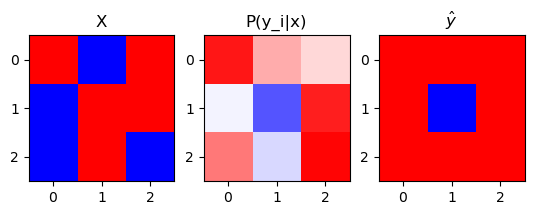

In [11]:
## EXAMPLE
x = np.random.choice(2**9)
y_hat = h(x)

fig, axs = plt.subplots(1, 3)

axs[0].imshow(int2img(x))
axs[0].set_title('X')

axs[1].imshow(Pyi[x], vmin=0, vmax=1)
axs[1].set_title('P(y_i|x)')

axs[2].imshow(int2img(y_hat))
axs[2].set_title(r'$\hat{y}$')

plt.show()

### Losses

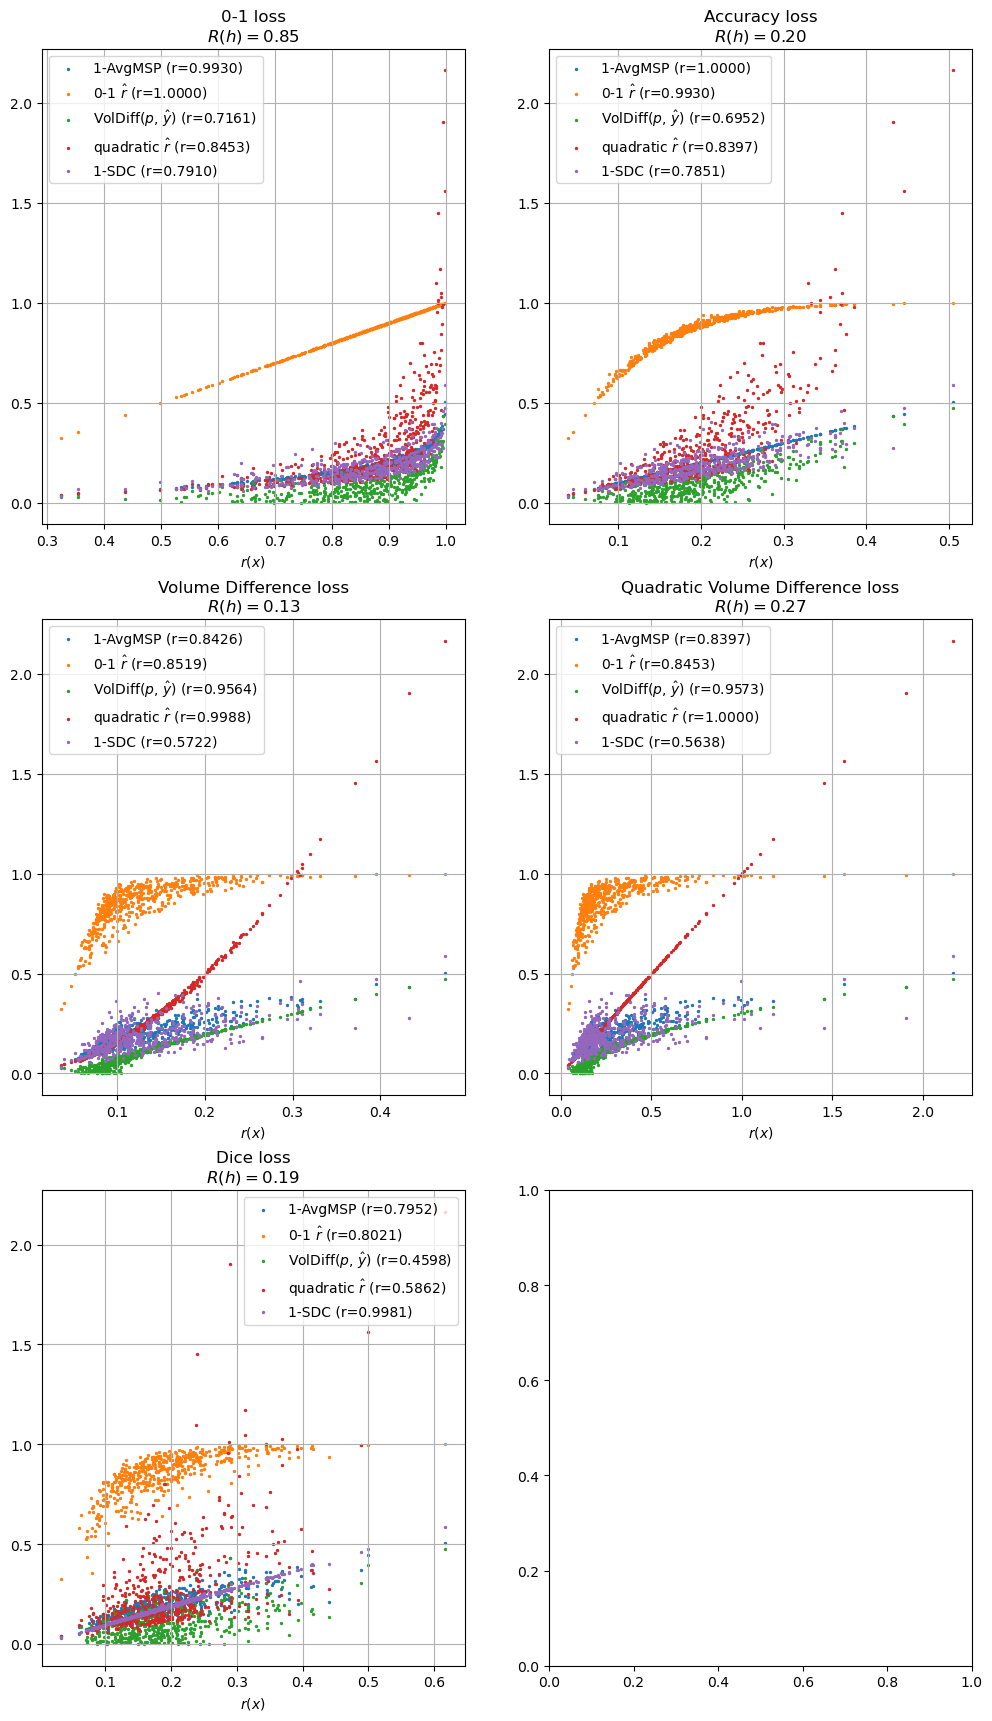

In [12]:
all_plots = [plot_01_loss, plot_accuracy_loss, plot_voldiff_loss, plot_quadvoldiff_loss, plot_dice_loss]
# fig, axs = plt.subplots(len(all_plots), 1, squeeze=True)
fig, axs = plt.subplots(int(len(all_plots)/2 + 0.5), 2, squeeze=True)
fig.set_size_inches(2*6, 7*int(len(all_plots)/2 + 0.5))

for plot_loss, ax in zip(all_plots, axs.flatten()):
    plot_loss(h, Py, Pyi, ax=ax)
plt.show()

### RC Curves

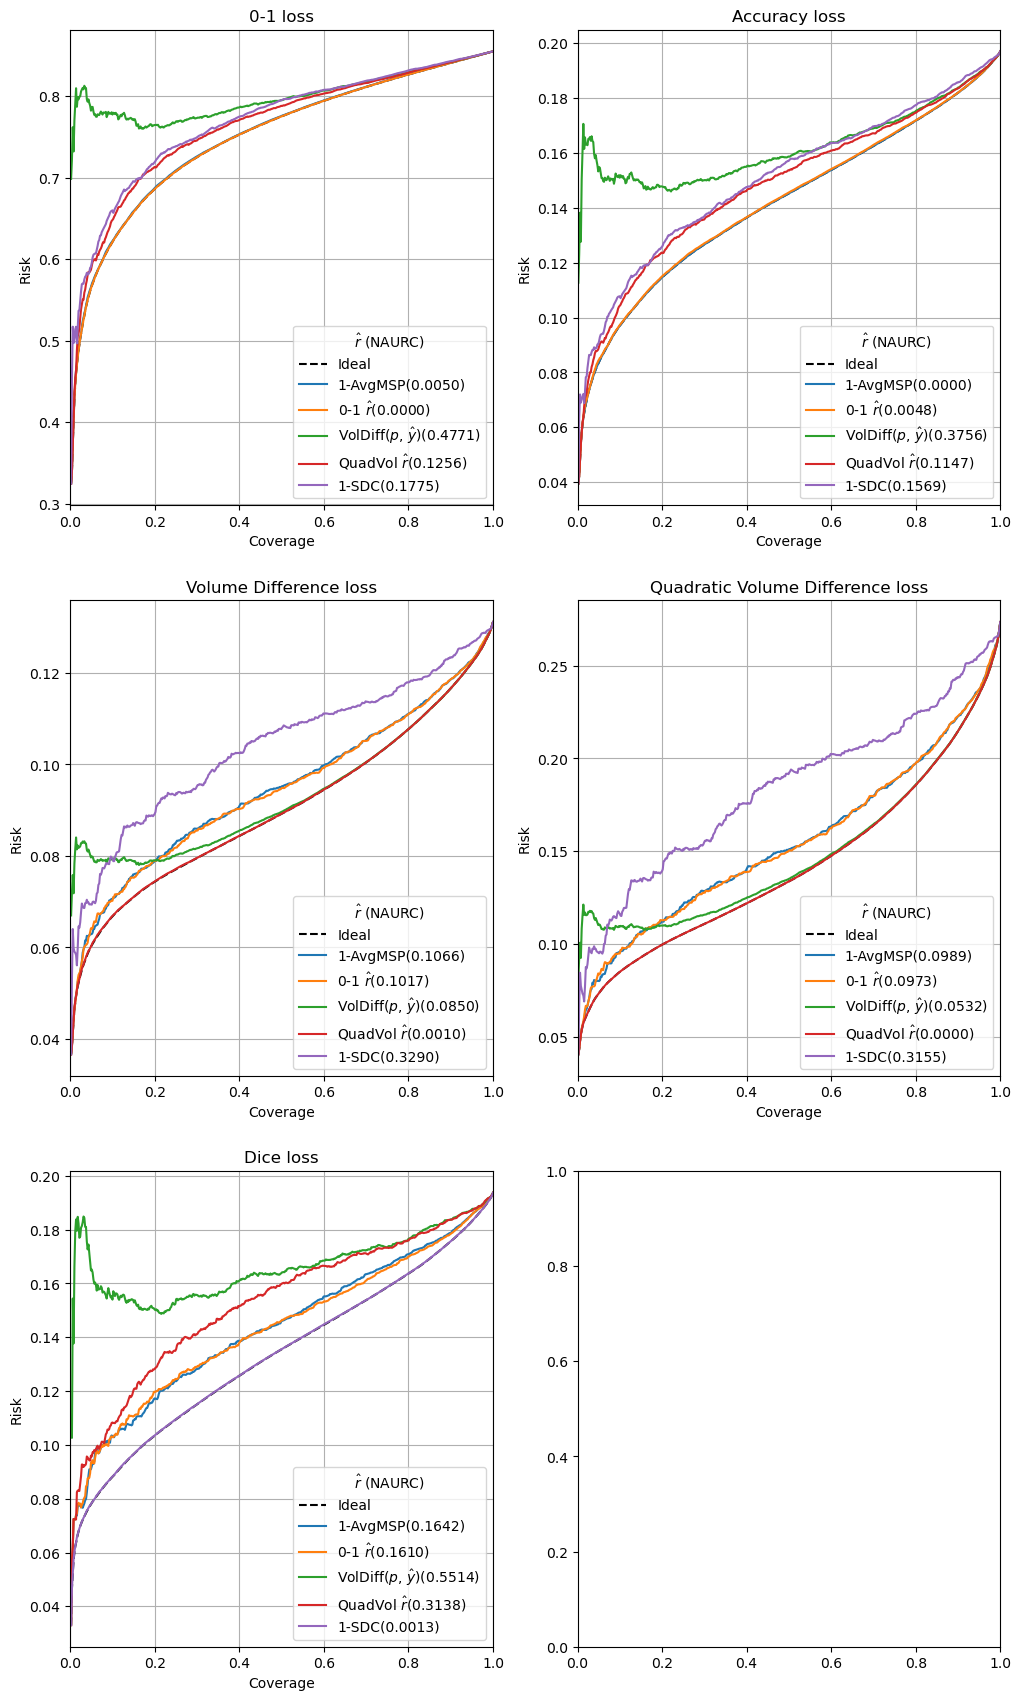

In [13]:
all_plots = [plot_01_rc, plot_accuracy_rc, plot_voldiff_rc, plot_quadvoldiff_rc, plot_dice_rc]
# all_plots = [plot_01_rc,]
# fig, axs = plt.subplots(len(all_plots), 1, squeeze=True)
fig, axs = plt.subplots(int(len(all_plots)/2 + 0.5), 2, squeeze=True)
fig.set_size_inches(2*6, 7*int(len(all_plots)/2 + 0.5))

for plot_rc, ax in zip(all_plots, axs.flatten()):
    plot_rc(h, Py, Pyi, ax=ax)
plt.show()

## Comments

This experiment is almost a sanity check. The only interesting empirical result is that there does not seem to be a "silver bullet" in terms of confidence estimator. However, this experiment confirms our theoretical results.